In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

sns.set(style="whitegrid")
sns.set_context("notebook", font_scale=1.2)
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', None)

In [ ]:

file_path = 'genres_v2.csv'
df = pd.read_csv(file_path, low_memory=False)

print(f"Dimensiones originales: {df.shape}")

audio_features = [
    'danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 
    'instrumentalness', 'liveness', 'valence', 'tempo'
]

df_audio = df[audio_features].copy()


df_audio = df_audio.dropna()
print(f"Dimensiones tras limpieza: {df_audio.shape}")

df_audio.head()

Dimensiones originales: (42305, 22)
Dimensiones tras limpieza: (42305, 9)


,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,0.831,0.814,-7.364,0.4200,0.0598,0.013400,0.0556,0.3890,156.985
1,0.719,0.493,-7.230,0.0794,0.4010,0.000000,0.1180,0.1240,115.080
2,0.850,0.893,-4.783,0.0623,0.0138,0.000004,0.3720,0.0391,218.050
3,0.476,0.781,-4.710,0.1030,0.0237,0.000000,0.1140,0.1750,186.948
4,0.798,0.624,-7.668,0.2930,0.2170,0.000000,0.1660,0.5910,147.988


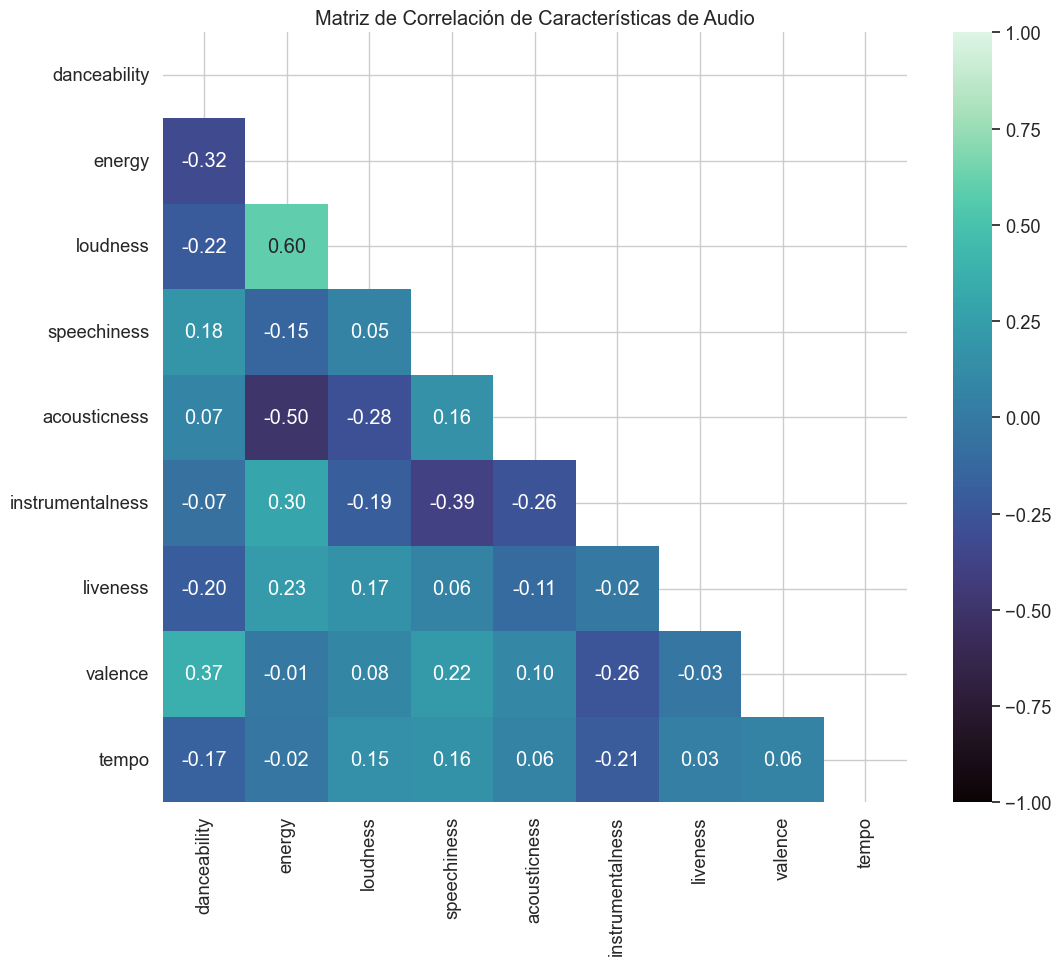

In [48]:
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(df_audio.corr(), dtype=bool))
sns.heatmap(df_audio.corr(), mask=mask, annot=True, fmt=".2f", cmap='mako', vmin=-1, vmax=1)
plt.title("Matriz de Correlación de Características de Audio")
plt.show()

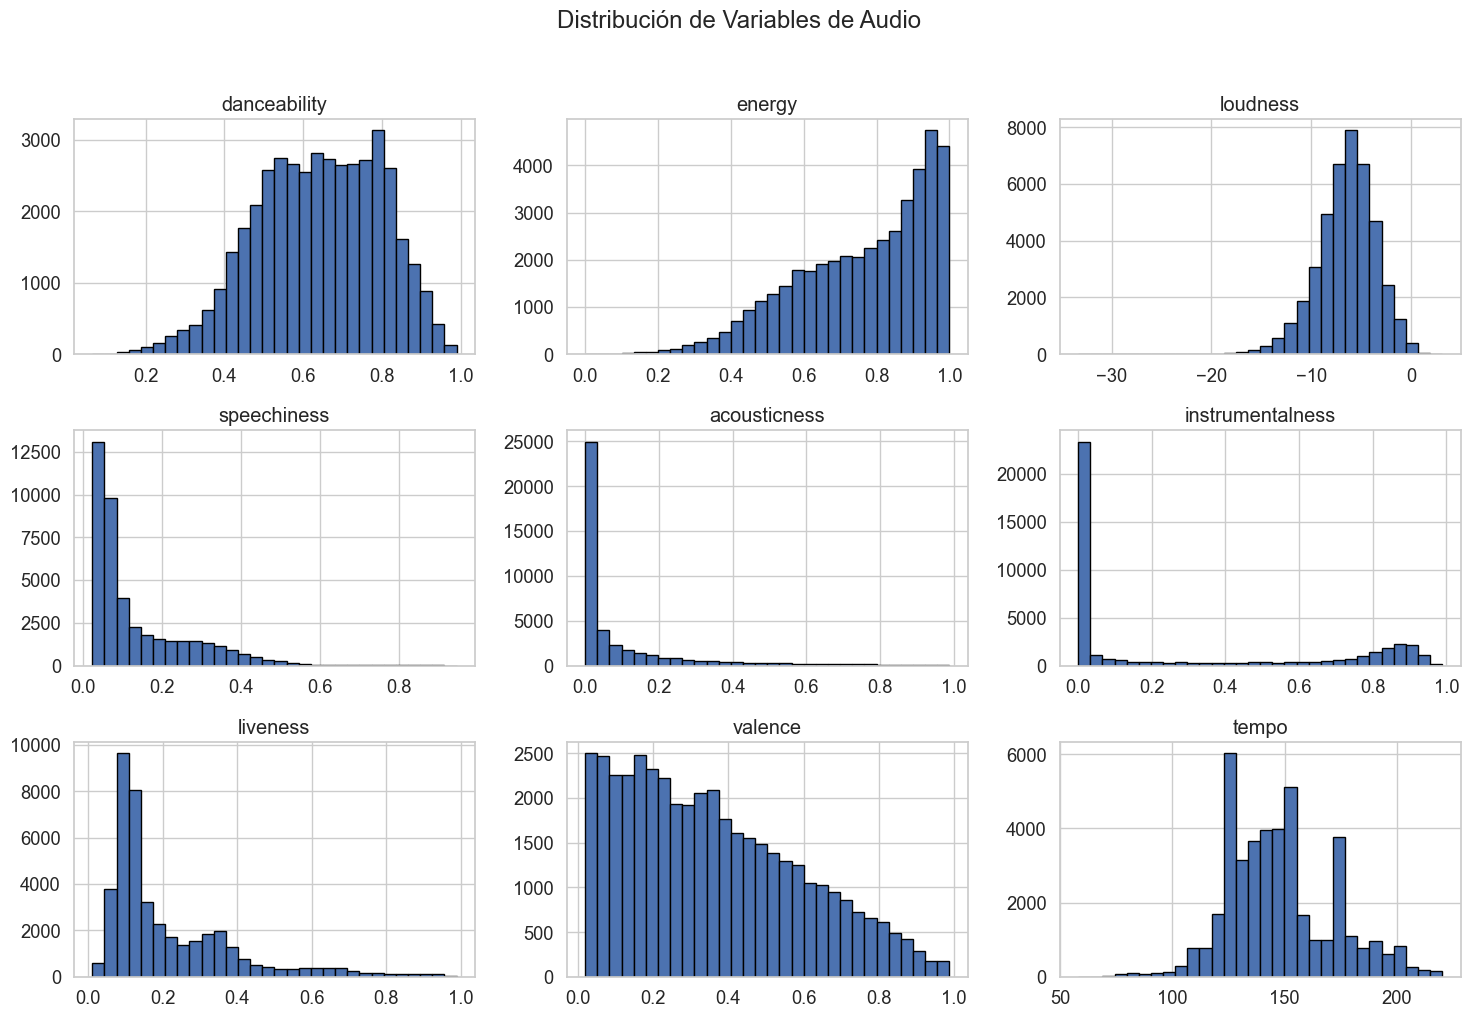

In [49]:
df_audio.hist(bins=30, figsize=(15, 10), color='#4c72b0', edgecolor='black')
plt.suptitle("Distribución de Variables de Audio", y=1.02)
plt.tight_layout()
plt.show()

In [50]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_audio)

df_scaled = pd.DataFrame(X_scaled, columns=df_audio.columns)

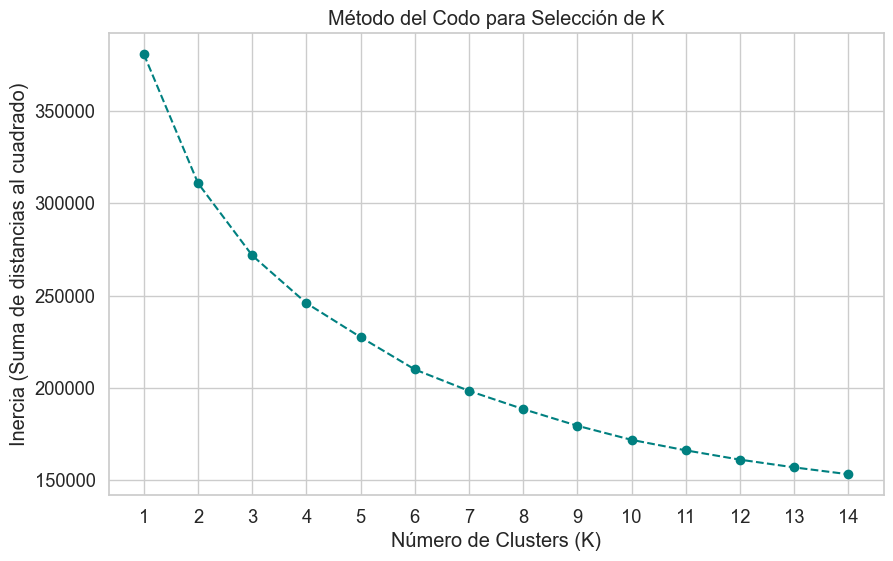

In [51]:
inertias = []
K_range = range(1, 15)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(K_range, inertias, marker='o', linestyle='--', color='teal')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inercia (Suma de distancias al cuadrado)')
plt.title('Método del Codo para Selección de K')
plt.xticks(K_range)
plt.grid(True)
plt.show()

In [52]:
k_optimo = 6  
kmeans_final = KMeans(n_clusters=k_optimo, random_state=42, n_init=20)
clusters = kmeans_final.fit_predict(X_scaled)

df_audio['Cluster'] = clusters
df_scaled['Cluster'] = clusters

print(f"Distribución de Clusters:\n{df_audio['Cluster'].value_counts().sort_index()}")

Distribución de Clusters:
Cluster
0    10536
1     3376
2     3495
3     7860
4     9985
5     7053
Name: count, dtype: int64


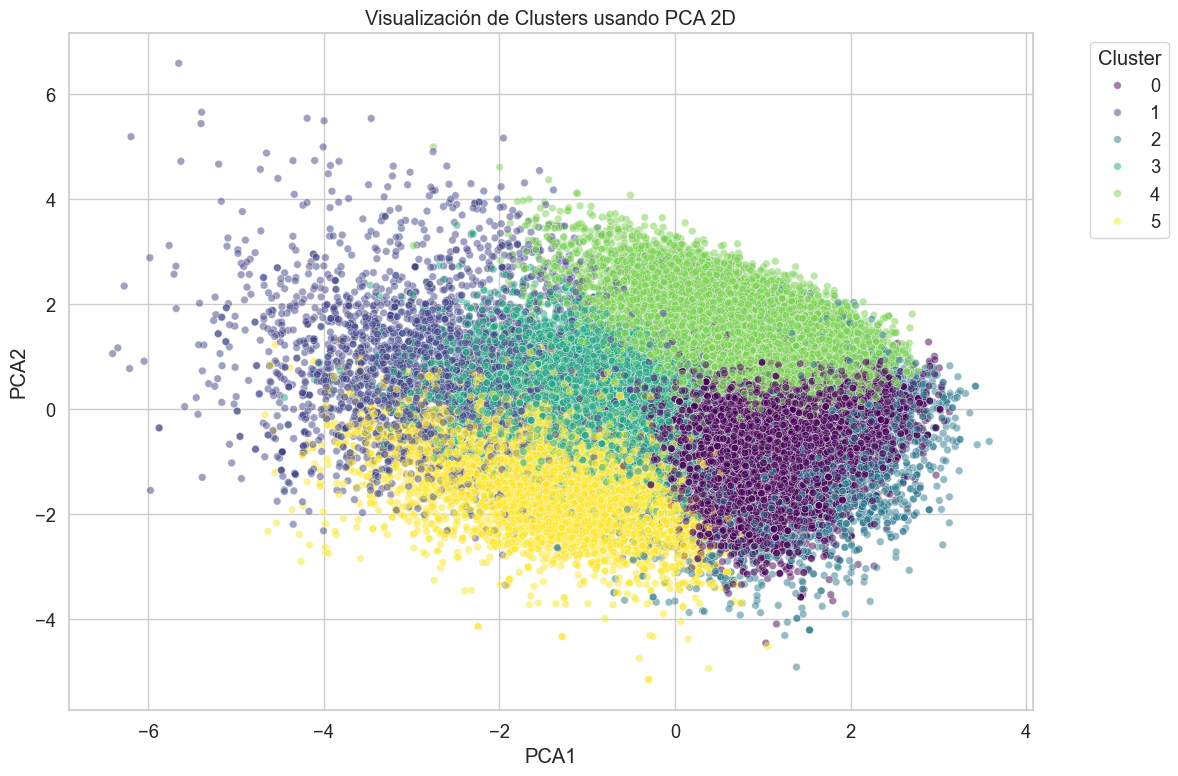

In [57]:
pca = PCA(n_components=2)
pca_embedding = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(pca_embedding, columns=['PCA1', 'PCA2'])
df_pca['Cluster'] = clusters

plt.figure(figsize=(12, 8))
sns.scatterplot(data=df_pca, x='PCA1', y='PCA2', hue='Cluster', palette='viridis', alpha=0.5, s=30)
plt.title("Visualización de Clusters usando PCA 2D")
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Ejecutando t-SNE...
[t-SNE] Computing 151 nearest neighbors...
[t-SNE] Indexed 42305 samples in 0.027s...
[t-SNE] Computed neighbors for 42305 samples in 2.453s...
[t-SNE] Computed conditional probabilities for sample 1000 / 42305
[t-SNE] Computed conditional probabilities for sample 2000 / 42305
[t-SNE] Computed conditional probabilities for sample 3000 / 42305
[t-SNE] Computed conditional probabilities for sample 4000 / 42305
[t-SNE] Computed conditional probabilities for sample 5000 / 42305
[t-SNE] Computed conditional probabilities for sample 6000 / 42305
[t-SNE] Computed conditional probabilities for sample 7000 / 42305
[t-SNE] Computed conditional probabilities for sample 8000 / 42305
[t-SNE] Computed conditional probabilities for sample 9000 / 42305
[t-SNE] Computed conditional probabilities for sample 10000 / 42305
[t-SNE] Computed conditional probabilities for sample 11000 / 42305
[t-SNE] Computed conditional probabilities for sample 12000 / 42305
[t-SNE] Computed conditional 

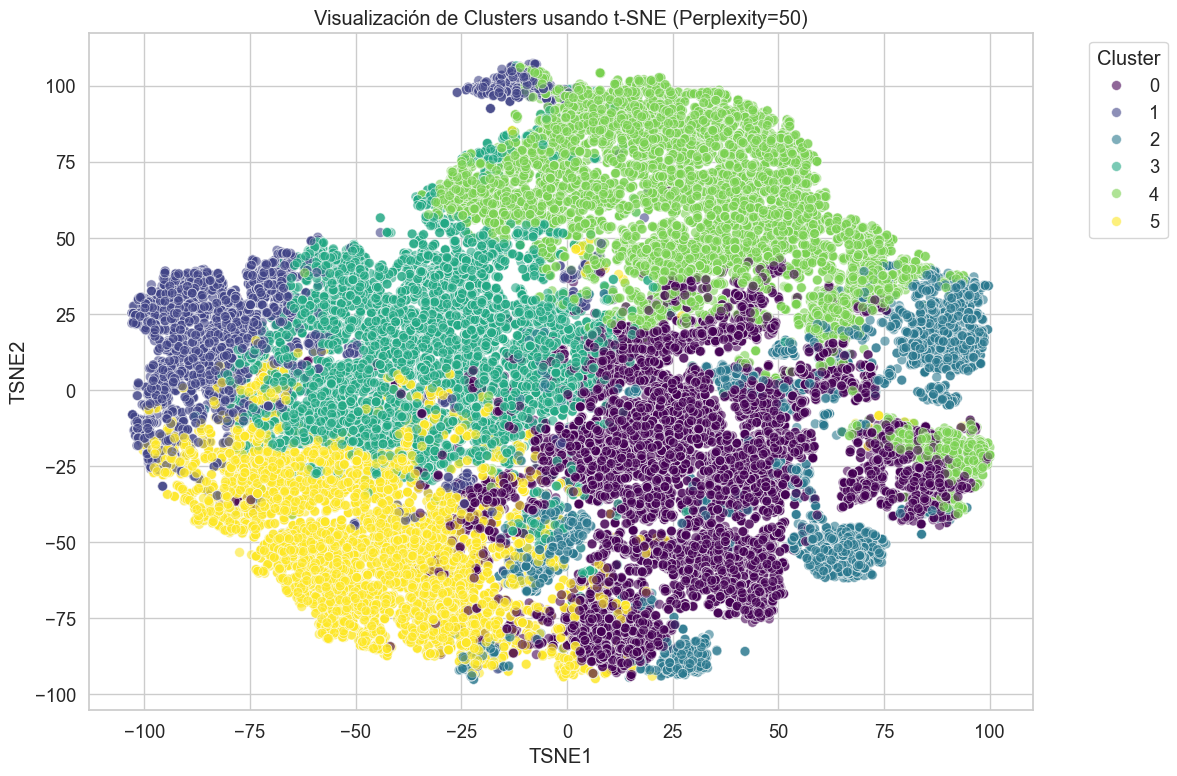

In [58]:
print("Ejecutando t-SNE...")
tsne = TSNE(n_components=2, perplexity=50, random_state=42, n_jobs=-1, verbose=1)
tsne_embedding = tsne.fit_transform(X_scaled)

df_tsne = pd.DataFrame(tsne_embedding, columns=['TSNE1', 'TSNE2'])
df_tsne['Cluster'] = clusters

plt.figure(figsize=(12, 8))
sns.scatterplot(data=df_tsne, x='TSNE1', y='TSNE2', hue='Cluster', palette='viridis', alpha=0.6, s=50)
plt.title("Visualización de Clusters usando t-SNE (Perplexity=50)")
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

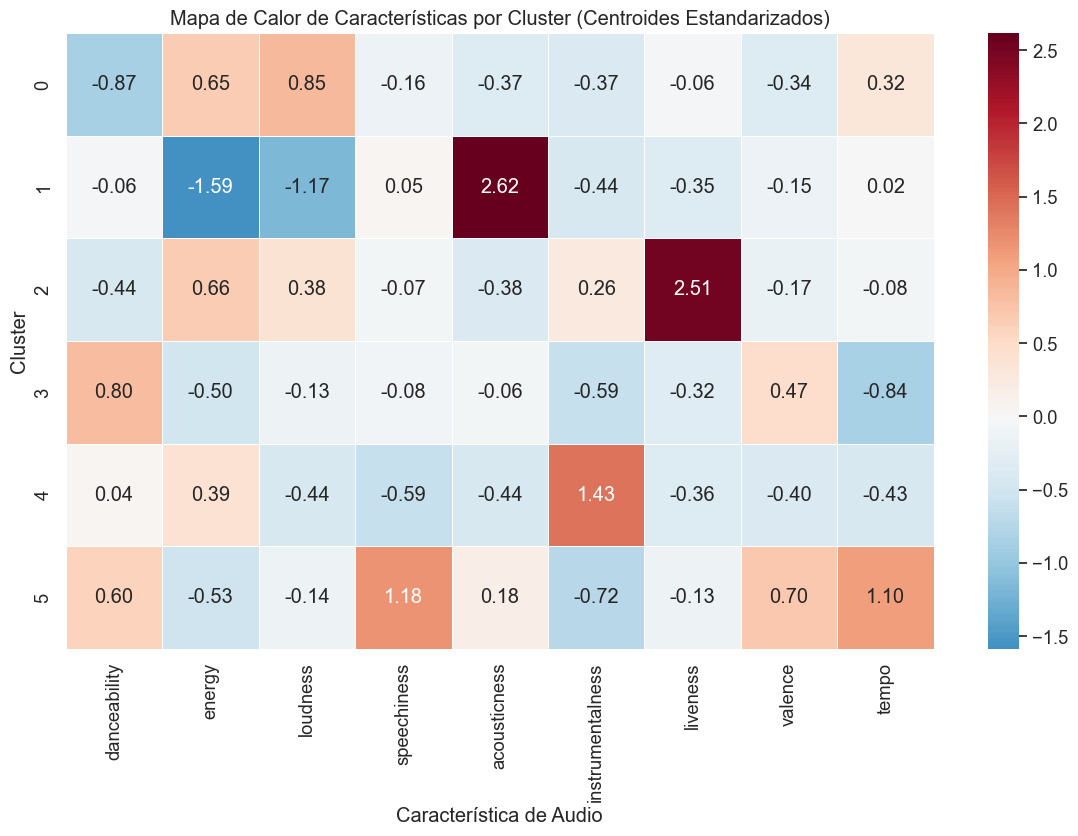

In [59]:

centroids_scaled = df_scaled.groupby('Cluster').mean()

plt.figure(figsize=(14, 8))

sns.heatmap(centroids_scaled, annot=True, cmap='RdBu_r', center=0, fmt=".2f", linewidths=0.5)
plt.title("Mapa de Calor de Características por Cluster (Centroides Estandarizados)")
plt.ylabel("Cluster")
plt.xlabel("Característica de Audio")
plt.show()